# 🔧 Predictive Maintenance System
## AI4I 2020 Dataset – End-to-End ML Pipeline

The problem addressed in this project is the inability of traditional maintenance systems to accurately predict machine failures. Existing approaches rely on fixed schedules or reactive maintenance, which either waste resources or fail to prevent breakdowns. Therefore, there is a need for a data-driven predictive system that can analyze sensor data and identify potential failures before they occur

In [2]:
# Install dependencies (uncomment if needed)
!pip install scikit-learn xgboost imbalanced-learn pandas numpy matplotlib seaborn joblib

## 1. Imports

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

print("All imports successful")

All imports successful


## 2. Load & Explore Data

In [4]:
df = pd.read_csv("ai4i2020.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64
Failure rate: 3.39%


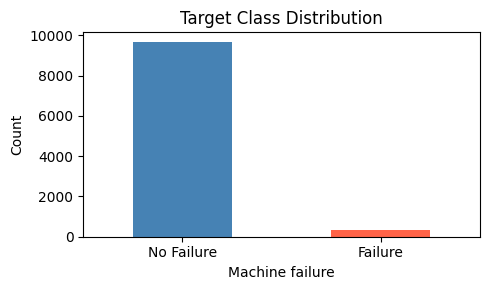

In [5]:
print("Target distribution:")
print(df["Machine failure"].value_counts())
print(f"Failure rate: {df['Machine failure'].mean()*100:.2f}%")

# Distribution of failure
fig, ax = plt.subplots(figsize=(5, 3))
df["Machine failure"].value_counts().plot(kind="bar", ax=ax, color=["steelblue","tomato"])
ax.set_xticklabels(["No Failure", "Failure"], rotation=0)
ax.set_title("Target Class Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## 3. Preprocessing

In [6]:
# Drop identifier columns
df = df.drop(columns=["UDI", "Product ID"])

# Drop failure-subtype columns (data leakage)
leakage = ["TWF", "HDF", "PWF", "OSF", "RNF"]
df = df.drop(columns=leakage)

# Encode categorical Type column
le = LabelEncoder()
df["Type"] = le.fit_transform(df["Type"])
print("Type encoding:", dict(zip(le.classes_, le.transform(le.classes_))))

# Sanitise column names for XGBoost (no brackets)
df.columns = [c.replace("[","(").replace("]",")").replace("<","lt") for c in df.columns]

X = df.drop(columns=["Machine failure"])
y = df["Machine failure"]

print(f"Features: {X.columns.tolist()}")
print(f"X shape: {X.shape}, y shape: {y.shape}")
df.describe()

Type encoding: {'H': np.int64(0), 'L': np.int64(1), 'M': np.int64(2)}
Features: ['Type', 'Air temperature (K)', 'Process temperature (K)', 'Rotational speed (rpm)', 'Torque (Nm)', 'Tool wear (min)']
X shape: (10000, 6), y shape: (10000,)


,Type,Air temperature (K),Process temperature (K),Rotational speed (rpm),Torque (Nm),Tool wear (min),Machine failure
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,1.19940,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,0.60023,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,0.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,1.00000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,1.00000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,2.00000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,2.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


## 4. Train / Test Split + SMOTE

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"After SMOTE – Train: {X_train_res.shape[0]} ({y_train_res.value_counts().to_dict()})")

Train: 8000 | Test: 2000
After SMOTE – Train: 15458 ({0: 7729, 1: 7729})


## 5. Model Training

In [17]:
# ── Random Forest ────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_split=5,
    class_weight="balanced", random_state=42, n_jobs=-1
)
rf.fit(X_train_res, y_train_res)
print("Random Forest trained")

Random Forest trained


In [18]:
# ── XGBoost ───────────────────────────────────────────────────
scale = (y_train_res == 0).sum() / (y_train_res == 1).sum()
xgb = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric="logloss", random_state=42, n_jobs=-1
)
xgb.fit(X_train_res, y_train_res)
print("XGBoost trained")

XGBoost trained


## 6. Evaluation

In [10]:
def evaluate(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1-Score":  f1_score(y_test, y_pred, zero_division=0),
    }

rf_m  = evaluate("Random Forest", rf,  X_test, y_test)
xgb_m = evaluate("XGBoost",       xgb, X_test, y_test)

comparison = pd.DataFrame([rf_m, xgb_m]).set_index("Model")
print(comparison.to_string())
comparison

               Accuracy  Precision    Recall  F1-Score
Model                                                 
Random Forest    0.9405   0.335484  0.764706  0.466368
XGBoost          0.9625   0.469565  0.794118  0.590164


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Random Forest,0.9405,0.335484,0.764706,0.466368
XGBoost,0.9625,0.469565,0.794118,0.590164


In [11]:
# Full classification reports
for name, model in [("Random Forest", rf), ("XGBoost", xgb)]:
    print(f"{'─'*50} {name} {'─'*50}")
    print(classification_report(y_test, model.predict(X_test), target_names=["No Failure","Failure"]))

────────────────────────────────────────────────── Random Forest ──────────────────────────────────────────────────
              precision    recall  f1-score   support

  No Failure       0.99      0.95      0.97      1932
     Failure       0.34      0.76      0.47        68

    accuracy                           0.94      2000
   macro avg       0.66      0.86      0.72      2000
weighted avg       0.97      0.94      0.95      2000

────────────────────────────────────────────────── XGBoost ──────────────────────────────────────────────────
              precision    recall  f1-score   support

  No Failure       0.99      0.97      0.98      1932
     Failure       0.47      0.79      0.59        68

    accuracy                           0.96      2000
   macro avg       0.73      0.88      0.79      2000
weighted avg       0.97      0.96      0.97      2000



## 7. Confusion Matrices

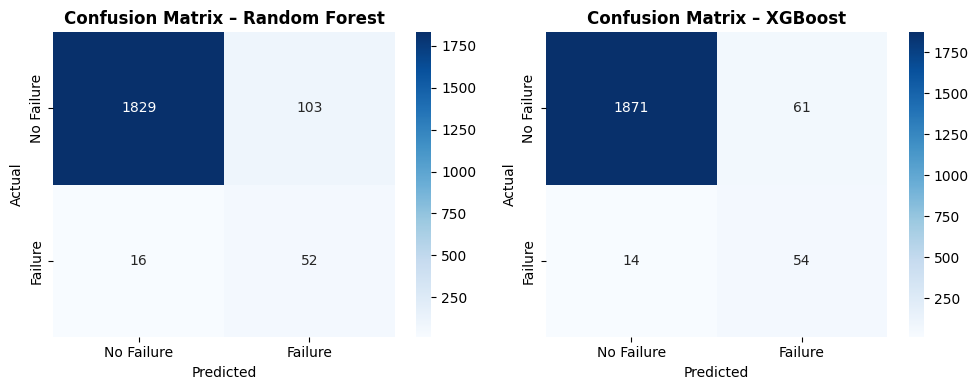

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, [("Random Forest", rf), ("XGBoost", xgb)]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Failure","Failure"],
                yticklabels=["No Failure","Failure"])
    ax.set_title(f"Confusion Matrix – {name}", fontweight="bold")
    ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")
plt.tight_layout()
plt.show()

## 8. Feature Importance

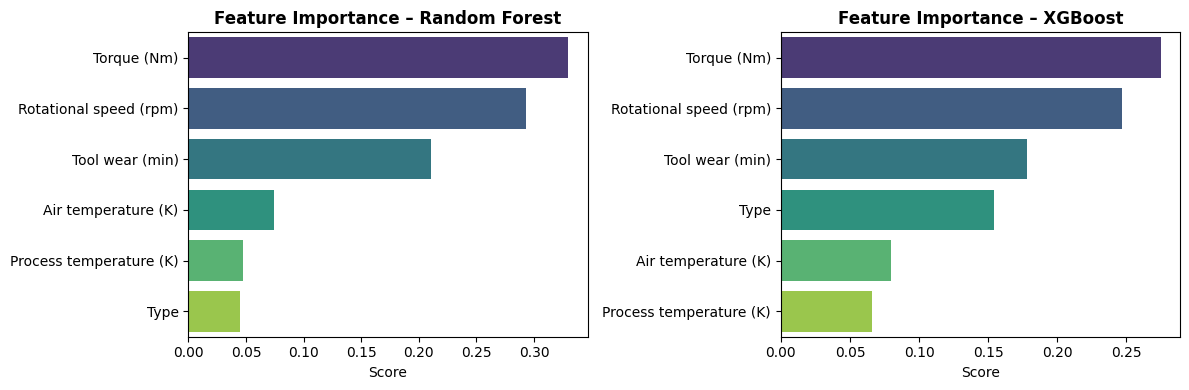

In [13]:
feature_names = X.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, model) in zip(axes, [("Random Forest", rf), ("XGBoost", xgb)]):
    importances = model.feature_importances_
    idx = np.argsort(importances)[::-1]
    sns.barplot(x=importances[idx], y=[feature_names[i] for i in idx], palette="viridis", ax=ax)
    ax.set_title(f"Feature Importance – {name}", fontweight="bold")
    ax.set_xlabel("Score")
plt.tight_layout()
plt.show()

## 9. Save Best Model

In [20]:
best_name  = "XGBoost" if xgb_m["F1-Score"] >= rf_m["F1-Score"] else "Random Forest"
best_model = xgb if best_name == "XGBoost" else rf

artifact = {"model": best_model, "feature_names": feature_names, "model_name": best_name}
joblib.dump(artifact, "model.pkl")
print(f"Best model ({best_name}) saved as model.pkl")

Best model (XGBoost) saved as model.pkl


## 10. Quick Inference Test

In [19]:
loaded    = joblib.load("model.pkl")
model_    = loaded["model"]
feat_ord  = loaded["feature_names"]

# Sample row: Type=M(2), slightly elevated torque, high tool wear
sample = pd.DataFrame([[2, 298.5, 308.6, 1551, 65.0, 220]], columns=feat_ord)
pred   = model_.predict(sample)[0]
prob   = model_.predict_proba(sample)[0][1]

print(f"Prediction : {'FAILURE' if pred == 1 else '✅ No Failure'}")
print(f"Probability: {prob*100:.1f}%")

Prediction : FAILURE
Probability: 99.6%
